In [1]:
import MDAnalysis as mda
from numpy import *
import os
from pylab import *
import MDAnalysis.analysis.distances
import MDAnalysis.analysis.rms
from MDAnalysis.analysis import align
import glob
#import umap
import scipy.stats
import sklearn
import sklearn.decomposition
import sklearn.preprocessing
import pandas as pd
import seaborn as sns
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA
import mdtraj

In [2]:
import os

########################################################
#############      FOR NOW EQPOINT IS 0   ##############
########################################################
EQPOINT=0

systemFolders = glob.glob("huNumbering/*t5a*/")

systemgros=[]
systemtprs=[]
systemtrjs=[]
for i in range(len(systemFolders)):
    systemgros.append(sorted(glob.glob(systemFolders[i]+"*.gro")))
    systemtprs.append(sorted(glob.glob(systemFolders[i]+"*.tpr")))
    systemtrjs.append(sorted(glob.glob(systemFolders[i]+"*.xtc")))


    
    
threeColor=["#FE6100","#332288","#882255"]
colourScheme= threeColor
system_names = ["rhT5A","T5A","T5AR332P"]
system_labels = [r"rhTRIM5$\alpha$",r"huTRIM5$\alpha$",r"huTRIM5$\alpha^{R332P}$"]

systems=[]
for i in range(len(systemgros)):
    sub=[]
    for j in range(len(systemgros[i])):
        # When using TPRs, residues are indexed from 1; so we need to add in the first residue, 1 - 1 + first resid=first resid
        #firstres = mda.Universe(systemgros[i][j]).residues.resids[0]-1
        tu = mda.Universe(systemgros[i][j],systemtrjs[i][j])
        #tu.residues.resids +=firstres
                          
        sub.append(tu)
        
    systems.append(sub)

rhresids = arange(292,496)
huresids = systems[1][0].residues.resids
    
protein=[]
proteinstrings=[]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein"))
        sub2.append("protein")
        
    protein.append(sub)
    proteinstrings.append(sub2)


bodys=[]
bodystrings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and not ("+combinedLoopString+")"))
        sub2.append("protein and not ("+combinedLoopString+")")
        
    bodys.append(sub)
    bodystrings.append(sub2)
    
    
v1s=[]
v1strings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v1s.append(sub)        
    v1strings.append(sub2)
                   

C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\topology\base.py:203: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  residx = np.zeros_like(criteria[0], dtype=np.int)
C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\core\selection.py:640: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: h

In [3]:
def getSSByRes(trjpaths,tprpaths,EQPOINT):
    
    helicityMap={"H":1,"E":0,"C":0}
    betacityMap={"H":0,"E":1,"C":0}
    coilicityMap={"H":0,"E":0,"C":1}
    
    helicity= []
    betacity= []
    coilicity=[]
    
    herr=[]
    berr=[]
    cerr=[]
    
    for i in range(len(trjpaths)):
        subH=[]
        subE=[]
        subC=[]
        for j in range(len(trjpaths[i])):
            t=mdtraj.load(trjpaths[i][j],top=tprpaths[i][j])
            ss1=mdtraj.compute_dssp(t,simplified=True)
            H1=zeros(ss1.shape)
            E1=zeros(ss1.shape)
            C1=zeros(ss1.shape)
            
            for ii in range(len(H1)):
                for jj in range(len(H1[ii])):
                    H1[ii][jj]=helicityMap[ss1[ii][jj]]
                    E1[ii][jj]=betacityMap[ss1[ii][jj]]
                    C1[ii][jj]=coilicityMap[ss1[ii][jj]]
                    
            H1byRes=mean(H1[EQPOINT:],axis=0)
            subH.append(H1byRes)
            
            E1byRes=mean(E1[EQPOINT:],axis=0)
            subE.append(E1byRes)
            C1byRes=mean(C1[EQPOINT:],axis=0)
            subC.append(C1byRes)
            
        helicity.append(subH)
        betacity.append(subE)
        coilicity.append(subC)

    return helicity,betacity,coilicity


helicity,betacity,coilcity=getSSByRes(systemtrjs,systemgros,EQPOINT=EQPOINT)


C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (LEU, GLU)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, residue.name))
C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (THR, LEU)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, residue.name))
C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (ASP, THR)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, residue.name))
C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (ALA, ASP)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, res

C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (ARG, VAL)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, residue.name))
C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (ALA, VAL)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, residue.name))
C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (CYS, SER)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, residue.name))
C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (GLU, SER)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, res

In [4]:
rhresids.shape

(204,)

In [5]:
#save("allhelicities.npy",helicity)
#save("allbetacities.npy",betacity)
#save("allcoilcities.npy",coilcity)

#for i in range(len(systems)):
#    save(system_names[i]+"helicities.npy",helicity[i])
#    save(system_names[i]+"betacities.npy",betacity[i])
#    save(system_names[i]+"coilcities.npy",coilcity[i])


#helicity=load("allhelicities.npy")
#betacity=load("allbetacities.npy")
#coilcity=load("allcoilcities.npy")

In [6]:
helicity=[]
betacity=[]
coilcity=[]
for i in range(len(systems)):
    helicity.append(load(system_names[i]+"helicities.npy"))
    betacity.append(load(system_names[i]+"betacities.npy"))
    coilcity.append(load(system_names[i]+"coilcities.npy"))

In [7]:
helicity[0].shape

(9, 204)

In [8]:
avghelicities = []
avgbetacities = []
avgcoilcities = []
semhelicities = []
sembetacities = []
semcoilcities = []
for i in range(len(helicity)):
    avghelicities.append(mean(helicity[i],axis = 0))
    avgbetacities.append(mean(betacity[i],axis = 0))
    avgcoilcities.append(mean(coilcity[i],axis = 0))
    semhelicities.append(scipy.stats.sem(helicity[i],axis = 0))
    sembetacities.append(scipy.stats.sem(betacity[i],axis = 0))
    semcoilcities.append(scipy.stats.sem(coilcity[i],axis = 0))
    

    
#Let's insert nans into the human versions so that everything stays aligned

def insertMyNans(huArray,indices):
    huList = list(huArray)
    # Note, index list should be in descending order, otherwise there will be problems 
    # (since the index of later indexes will increase every time you make an insertion)
    for i in range(len(indices)):
        huList.insert(indices[i],nan)
    return array(huList)
 #INSERT NANS
for i in range(1,len(avghelicities)):
    avghelicities[i] = insertMyNans(avghelicities[i],indices = [338-290,338-290])
    avgbetacities[i] = insertMyNans(avgbetacities[i],indices = [338-290,338-290])
    avgcoilcities[i] = insertMyNans(avgcoilcities[i],indices = [338-290,338-290])
    semhelicities[i] = insertMyNans(semhelicities[i],indices = [338-290,338-290])
    sembetacities[i] = insertMyNans(sembetacities[i],indices = [338-290,338-290])
    semcoilcities[i] = insertMyNans(semcoilcities[i],indices = [338-290,338-290])


In [9]:
avghelicities

[array([0.00000000e+00, 9.92779583e-01, 9.97639479e-01, 9.97944958e-01,
        9.98889167e-01, 8.94276431e-01, 4.75325613e-01, 3.64297814e-01,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        5.55416701e-05, 5.55416701e-05, 5.55416701e-05, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 3.87403149e-02,
        4.90155239e-02, 6.76497542e-02, 6.73720459e-02, 5.80965870e-02,
        2.26610014e-02, 3.33250021e-04, 4.49887528e-03, 9.94195895e-03,
        1.65236469e-02, 1.54405843e-02, 1.13582715e-02, 2.08281263e-03,
        0.00000000e+00, 8.27570885e-03, 8.47010470e-03, 4.36002111e-02,
        4.04343359e-02, 4.06842734e-02, 2.98814185e-02, 2.666000

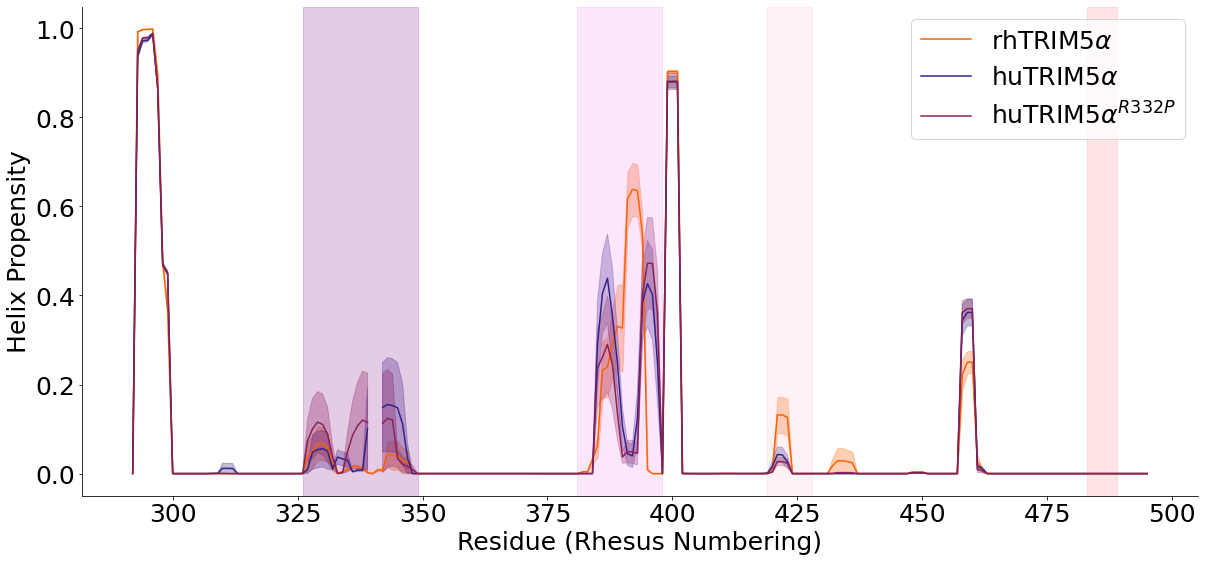

In [20]:
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False

figure(figsize = (20,9))
for i in range(0,3):#len(avghelicities)):
    
    plot(rhresids,avghelicities[i],color = colourScheme[i],label = system_labels[i])
    fill_between(rhresids, avghelicities[i] - semhelicities[i],avghelicities[i] + semhelicities[i],color = colourScheme[i],alpha = 0.3)

    
    
xlabel("Residue (Rhesus Numbering)",fontsize = 25)
ylabel("Helix Propensity",fontsize = 25)
xticks(fontsize = 25)
yticks(fontsize = 25)
legend(fontsize = 25)
#xlim(325,350)
#axvline(332)
#ylim(0,0.3)
#xlim(380,400)


axvspan(326,349,color = "purple", alpha = 0.2)
axvspan(381,398,color = "violet", alpha = 0.2)
axvspan(419,428,color = "pink", alpha = 0.2)
axvspan(483,489,color = "red", alpha = 0.1)

In [21]:

#FOR RHESUS NUMBERING
#figure(figsize = (16,10))
#for i in range(0,3):#len(avghelicities)):
#    
#    plot(rhresids,avghelicities[i],color = colourScheme[i],label = system_labels[i])
#    fill_between(rhresids, avghelicities[i] - semhelicities[i],avghelicities[i] + semhelicities[i],color = colourScheme[i],alpha = 0.3)
#
#    
#    
#xlabel("Residue",fontsize = 25)
#ylabel("Helix Propensity",fontsize = 25)
#xticks(fontsize = 25)
#yticks(fontsize = 25)
#legend(fontsize = 25)
#xlim(320,350)
#axvline(290)
#ylim(0,0.3)

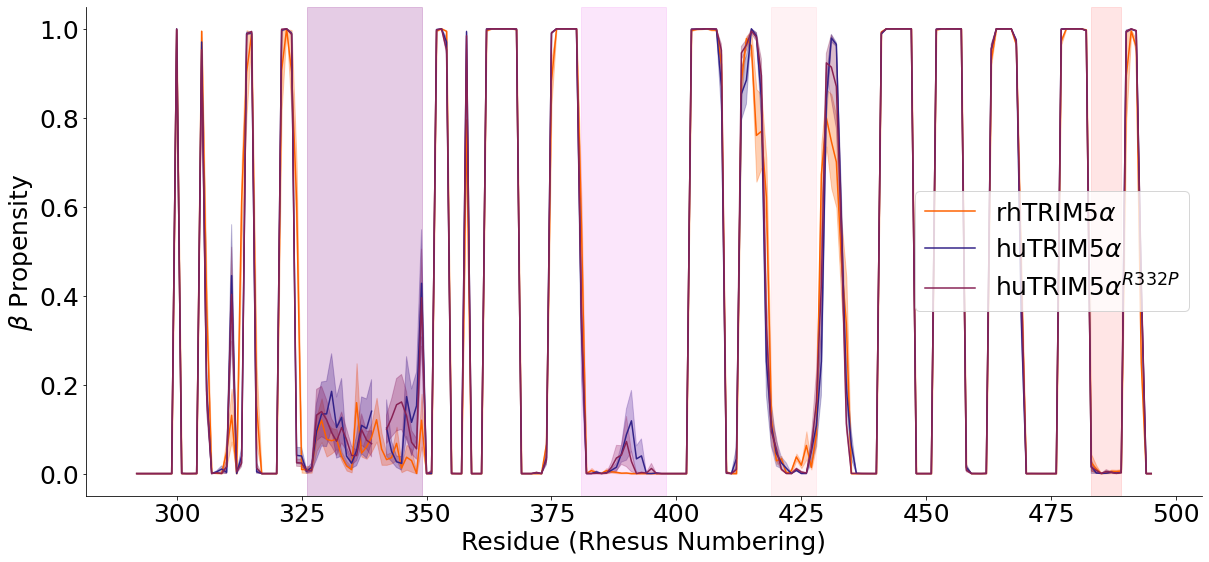

In [22]:
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False

figure(figsize = (20,9))
for i in range(0,3):#len(avghelicities)):
    
    plot(rhresids,avgbetacities[i],color = colourScheme[i],label = system_labels[i])
    fill_between(rhresids, avgbetacities[i] - sembetacities[i],avgbetacities[i] + sembetacities[i],color = colourScheme[i],alpha = 0.3)

xlabel("Residue (Rhesus Numbering)",fontsize = 25)
ylabel(r"$\beta$ Propensity",fontsize = 25)
xticks(fontsize = 25)
yticks(fontsize = 25)
legend(fontsize = 25,loc = "right")

axvspan(326,349,color = "purple", alpha = 0.2)
axvspan(381,398,color = "violet", alpha = 0.2)
axvspan(419,428,color = "pink", alpha = 0.2)
axvspan(483,489,color = "red", alpha = 0.1)

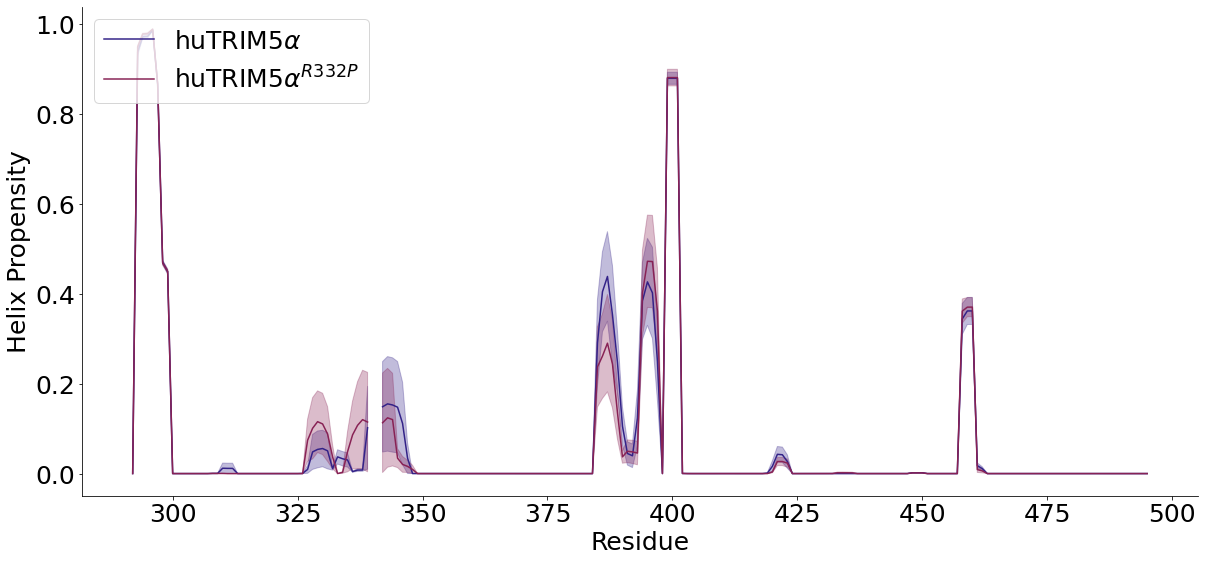

In [23]:
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False

figure(figsize = (20,9))
for i in range(1,3):#len(avghelicities)):
    
    plot(rhresids,avghelicities[i],color = colourScheme[i],label = system_labels[i])
    fill_between(rhresids, avghelicities[i] - semhelicities[i],avghelicities[i] + semhelicities[i],color = colourScheme[i],alpha = 0.3)
    
xlabel("Residue",fontsize = 25)
ylabel("Helix Propensity",fontsize = 25)
xticks(fontsize = 25)
yticks(fontsize = 25)
legend(fontsize = 25,loc = "upper left")

##xlim(405,430)
#ylim(0,0.6)
#axvline(342)
#xlim(324,347)

(370.0, 410.0)

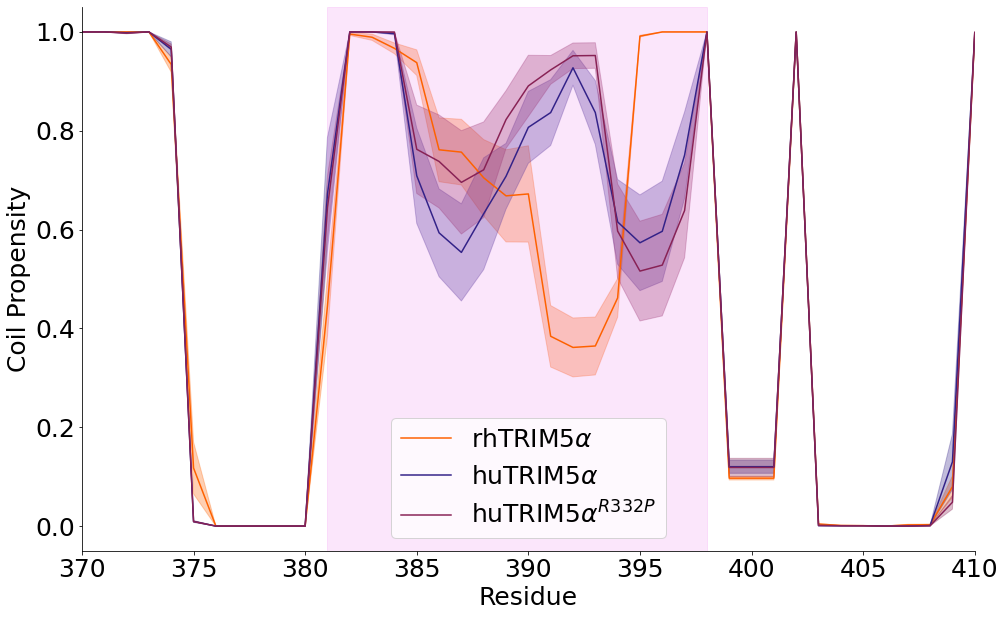

In [24]:
figure(figsize = (16,10))
for i in range(0,3):#len(avghelicities)):
    
    plot(rhresids,avgcoilcities[i],color = colourScheme[i],label = system_labels[i])
    fill_between(rhresids, avgcoilcities[i] - semcoilcities[i],avgcoilcities[i] + semcoilcities[i],color = colourScheme[i],alpha = 0.3)

    
    
xlabel("Residue",fontsize = 25)
ylabel("Coil Propensity",fontsize = 25)
xticks(fontsize = 25)
yticks(fontsize = 25)
legend(fontsize = 25)


axvspan(326,349,color = "purple", alpha = 0.2)
axvspan(381,398,color = "violet", alpha = 0.2)
axvspan(419,428,color = "pink", alpha = 0.2)
axvspan(483,489,color = "red", alpha = 0.1)



xlim(370,410)




In [15]:
def getSSByRes_ts(trjpaths,tprpaths,EQPOINT):
    
    helicityMap={"H":1,"E":0,"C":0}
    betacityMap={"H":0,"E":1,"C":0}
    coilicityMap={"H":0,"E":0,"C":1}
    
    helicity= []
    betacity= []
    coilicity=[]
    
    herr=[]
    berr=[]
    cerr=[]
    
    for i in range(len(trjpaths)):
        subH=[]
        subE=[]
        subC=[]
        for j in range(len(trjpaths[i])):
            t=mdtraj.load(trjpaths[i][j],top=tprpaths[i][j])
            ss1=mdtraj.compute_dssp(t,simplified=True)
            H1=zeros(ss1.shape)
            E1=zeros(ss1.shape)
            C1=zeros(ss1.shape)
            
            for ii in range(len(H1)):
                for jj in range(len(H1[ii])):
                    H1[ii][jj]=helicityMap[ss1[ii][jj]]
                    E1[ii][jj]=betacityMap[ss1[ii][jj]]
                    C1[ii][jj]=coilicityMap[ss1[ii][jj]]
                    
            H1byRes=H1[EQPOINT:]
            subH.append(H1byRes)
            
            E1byRes=E1[EQPOINT:]
            subE.append(E1byRes)
            C1byRes=C1[EQPOINT:]
            subC.append(C1byRes)
            
        helicity.append(subH)
        betacity.append(subE)
        coilicity.append(subC)

    return helicity,betacity,coilicity


helicity_ts,betacity_ts,coilcity_ts=getSSByRes_ts(systemtrjs,systemgros,EQPOINT=EQPOINT)



#save("helicity_ts.npy",helicity_ts)

C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (LEU, GLU)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, residue.name))
C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (THR, LEU)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, residue.name))
C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (ASP, THR)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, residue.name))
C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (ALA, ASP)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, res

C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (ARG, VAL)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, residue.name))
C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (ALA, VAL)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, residue.name))
C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (CYS, SER)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, residue.name))
C:\Users\Liam\anaconda3\lib\site-packages\mdtraj\formats\gro.py:307: UserWarning: WARNING: two consecutive residues with same number (GLU, SER)
  warnings.warn("WARNING: two consecutive residues with same number (%s, %s)" % (thisresname, res

In [16]:
#for i in range(len(systems)):
#    save(system_names[i]+"helicities_ts.npy",helicity_ts[i])
#    save(system_names[i]+"betacities_ts.npy",betacity_ts[i])
#    save(system_names[i]+"coilcities_ts.npy",coilcity_ts[i])

In [17]:
helicity_ts=[]
betacity_ts=[]
coilcity_ts=[]
for i in range(len(systems)):
    helicity_ts.append(load(system_names[i]+"helicities_ts.npy"))
    betacity_ts.append(load(system_names[i]+"betacities_ts.npy"))
    coilcity_ts.append(load(system_names[i]+"coilcities_ts.npy"))

In [18]:
helicity_ts[0].shape

(9, 4001, 204)

In [19]:
plot(betacity_ts

SyntaxError: unexpected EOF while parsing (<ipython-input-19-3f4b5ee8445a>, line 1)

In [ ]:
figure(figsize = (20,10))
plot(betacity_ts[1][:,:,50].flatten())

In [ ]:
systems